In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

df_raw = pd.read_csv('../data/spiff_data-2_filled.csv')

df_raw = df_raw.set_index('day')

df_prices = df_raw[var_names].iloc[2000:]
print(f"Clean price panel: {df_prices.shape}, days {int(df_prices.index[0])}...{int(df_prices.index[-1])}")
df_prices.tail()

Clean price panel: (3256, 7), days 2001...5256


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
5252,13.790362,8.236738,6.451460,6.706903,2.972465,8.751953,11.767324
5253,13.798624,8.134064,6.406032,6.677940,2.960002,8.730038,11.830896
5254,13.800276,8.191484,6.444321,6.655631,2.837448,8.748910,12.129688
5255,13.773631,8.123846,6.370987,6.593250,2.851988,8.742213,12.118563
5256,13.791949,8.084917,6.419011,6.512971,2.760591,8.738561,12.231405


Zentered to mean zero:

In [60]:
df_returns = df_prices.pct_change().dropna()
mean_return = df_returns.mean()
df_returns_centered = df_returns - mean_return
print("Per-series mean return:")
print(mean_return.round(6))
df_returns_centered.head()

Per-series mean return:
gurkor          0.000207
guitars         0.000102
slingshots      0.000348
stocks          0.000170
sugar           0.000130
water           0.000168
tranquillity    0.000176
dtype: float64


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
2002,-0.000361,-0.003041,0.017894,-0.000171,0.004612,0.002207,-0.016988
2003,-0.002830,0.027539,0.000990,0.016143,-0.013616,0.000211,0.003928
2004,-0.001135,0.003054,0.000885,-0.000136,-0.011066,-0.001305,0.007317
2005,-0.002529,0.018631,0.027689,0.013308,0.002634,0.000116,0.009966
2006,0.001500,-0.002769,-0.003545,0.006945,0.028126,0.002108,-0.010886


In [61]:
Y = df_returns_centered.values                # (T, 7)
T, k = Y.shape

# Build lagged regressors
X = np.column_stack([Y[1:-1], Y[:-2]])        # (T-2, 14): [r_{t-1}, r_{t-2}]
Y_t = Y[2:]                                   # (T-2, 7)

# OLS: B has shape (14, 7); rows 0..6 -> Phi1^T, rows 7..13 -> Phi2^T
B, *_ = np.linalg.lstsq(X, Y_t, rcond=None)
Phi1 = B[:k].T
Phi2 = B[k:].T

# Residual covariance
resid = Y_t - X @ B
Sigma_eps = np.cov(resid, rowvar=False)
L_eps = np.linalg.cholesky(Sigma_eps + 1e-12 * np.eye(k))
print(Phi1)
print(Phi2)

print("Phi1 diagonal:", np.round(np.diag(Phi1), 3))
print("Phi2 diagonal:", np.round(np.diag(Phi2), 3))
print(f"Residual std (per series): {np.round(np.sqrt(np.diag(Sigma_eps)), 5)}")


[[-0.03415056  0.0051223  -0.00410971  0.00118431  0.0007329   0.05198414
   0.00673216]
 [-0.15736678 -0.16111704  0.25018651 -0.01069532 -0.03840424  0.08818481
  -0.06114669]
 [ 0.07735161  0.10038906 -0.12550289 -0.02093887 -0.00552357  0.06384935
  -0.02862877]
 [ 0.0352599  -0.00987946 -0.01549737 -0.0124483   0.02870877 -0.04697957
  -0.00413402]
 [-0.087931    0.29048923  0.27837277  0.01243727 -0.18525652 -0.02737874
   0.00818257]
 [ 0.18874021  0.0213453  -0.02475284  0.00507941 -0.00808196 -0.12628063
   0.01309402]
 [ 0.03177548 -0.03229057  0.1253589   0.01189465 -0.06007132 -0.03997295
  -0.06288139]]
[[-0.08802293  0.00111315 -0.00551246  0.00134803  0.00287328  0.0192825
  -0.00628959]
 [-0.1233616  -0.06827138  0.08315927  0.01775575 -0.04342401 -0.09327769
   0.0080719 ]
 [-0.13558965 -0.00621764  0.01287213  0.02236973 -0.02643568  0.04193183
  -0.02221903]
 [-0.01282267  0.01448558  0.00142663 -0.0264261   0.00646678  0.1388725
  -0.01070304]
 [ 0.03909724  0.00511

Residual cross-correlations — mean |rho|: 0.216, max |rho|: 0.646


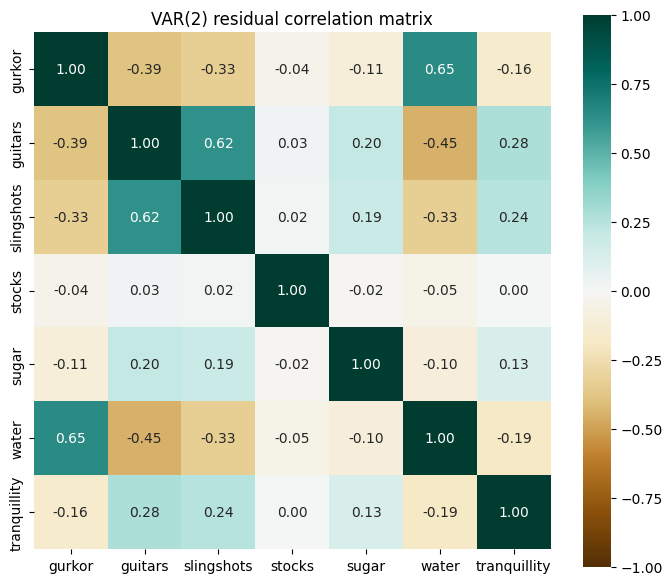

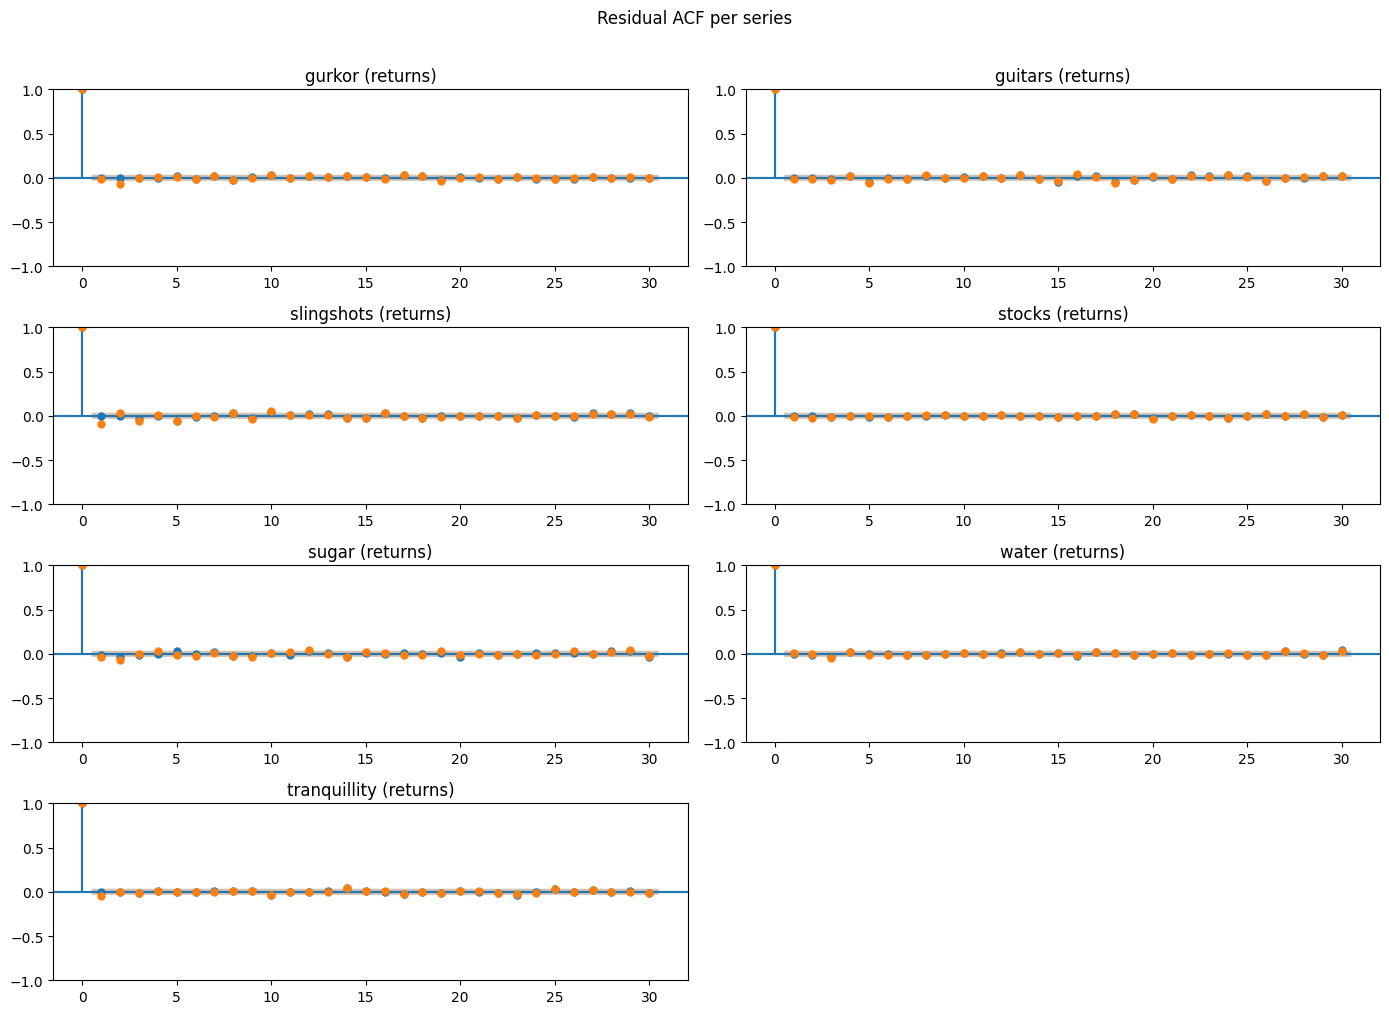

In [62]:
# --- VAR(2) residual diagnostics ---
# If the VAR captures the joint dynamics, residuals should be (i) uncorrelated
# across series and (ii) uncorrelated in time. Inspect the correlation matrix
# of residuals and the per-series ACFs.

import seaborn as sns

resid_corr = pd.DataFrame(resid, columns=var_names).corr()

off = resid_corr.values[~np.eye(k, dtype=bool)]
print(f"Residual cross-correlations — mean |rho|: {np.abs(off).mean():.3f}, "
      f"max |rho|: {np.abs(off).max():.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(resid_corr, annot=True, fmt='.2f', cmap='BrBG', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('VAR(2) residual correlation matrix')
plt.tight_layout()
plt.show()

# Per-series residual ACF — confirms no temporal info left
from statsmodels.graphics.tsaplots import plot_acf
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
for ax, name, i in zip(axes.flat, var_names, range(k)):
    plot_acf(resid[:, i], lags=30, ax=ax, title=name)
    plot_acf(df_returns_centered.values[:, i], lags=30, ax=ax, title=name + ' (returns)', alpha=0.05)
axes.flat[-1].axis('off')
plt.suptitle('Residual ACF per series', y=1.01)
plt.tight_layout()
plt.show()



Phi1 (raw)
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor        -0.034    0.005      -0.004   0.001  0.001  0.052         0.007
guitars       -0.157   -0.161       0.250  -0.011 -0.038  0.088        -0.061
slingshots     0.077    0.100      -0.126  -0.021 -0.006  0.064        -0.029
stocks         0.035   -0.010      -0.015  -0.012  0.029 -0.047        -0.004
sugar         -0.088    0.290       0.278   0.012 -0.185 -0.027         0.008
water          0.189    0.021      -0.025   0.005 -0.008 -0.126         0.013
tranquillity   0.032   -0.032       0.125   0.012 -0.060 -0.040        -0.063

Phi2 (raw)
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor        -0.088    0.001      -0.006   0.001  0.003  0.019        -0.006
guitars       -0.123   -0.068       0.083   0.018 -0.043 -0.093         0.008
slingshots    -0.136   -0.006       0.013   0.022 -0.026  0.042        -0.022
stocks        -0.013    0.014       0.00

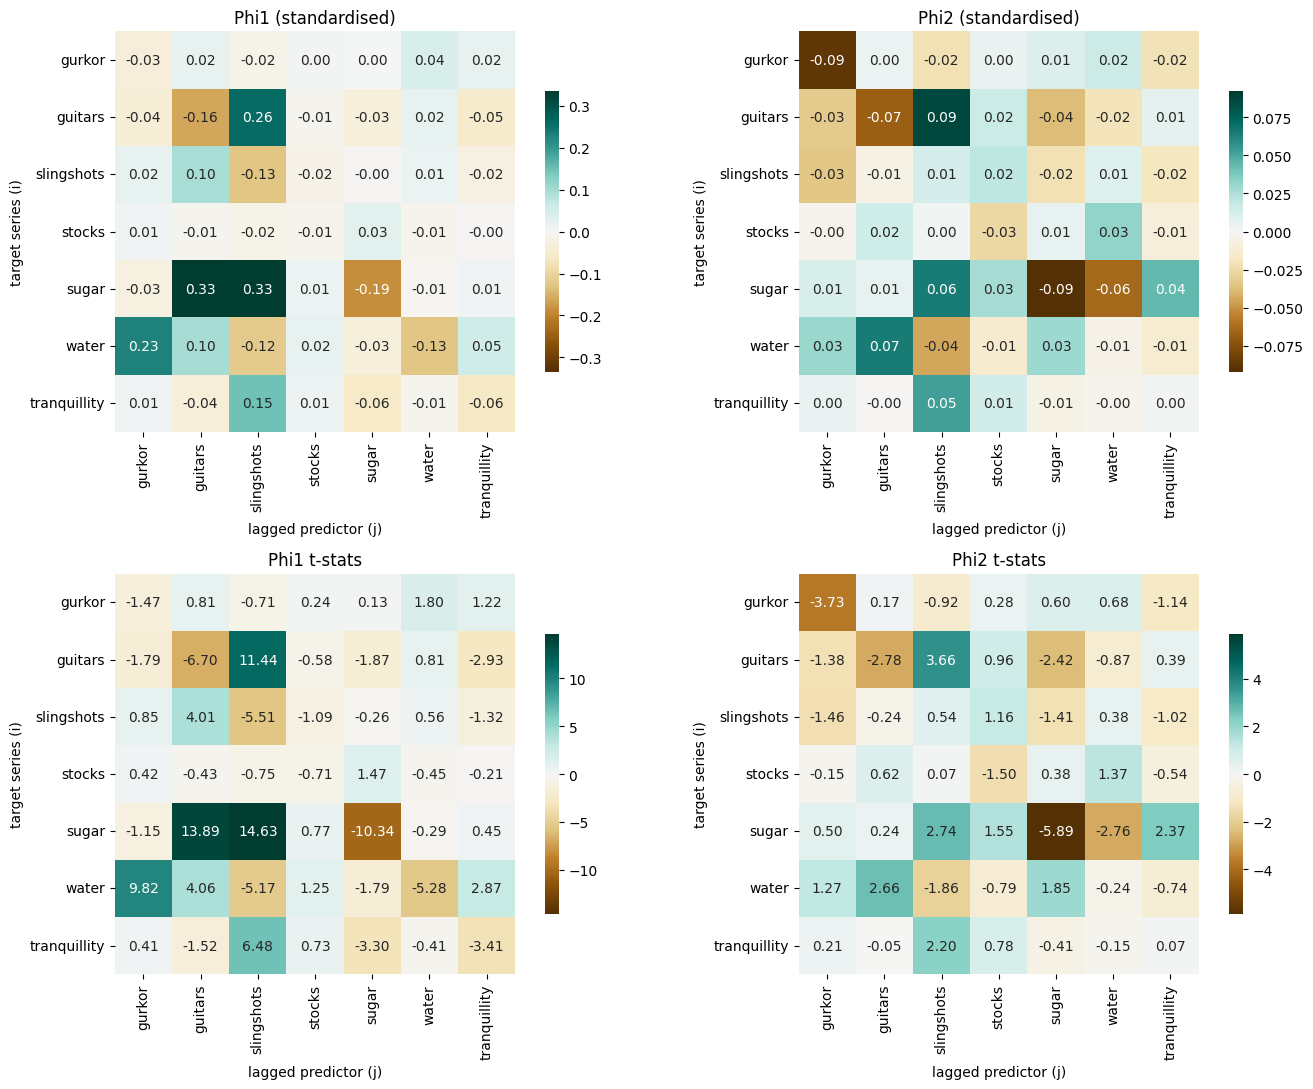


Trace(Cov(Y_t))                          = 0.001219
Trace(Sigma_eps) — full VAR(2)           = 0.001128
Trace(resid cov) — 7 indep AR(2)s        = 0.001214
Variance explained by full VAR(2):         7.469%
Variance explained by 7 indep AR(2)s:      0.383%
Extra explained by cross-lag terms:        7.086%
Off-diagonal share of sum|Phi|:            79.2%
Significant entries (|t|>1.96): 26 / 98 (27%)


In [63]:
# --- Phi diagnostics: are the off-diagonals doing real work? ---
# 1. Phi1, Phi2 coefficients (raw)
# 2. t-statistics for each entry (OLS standard errors)
# 3. Standardised Phi: tilde_Phi_ij = Phi_ij * sigma_j / sigma_i (scale-free)
# 4. Variance explained: multivariate VAR vs 7 independent AR(2)s

# OLS SE for B (14 x 7). Same-regressors SUR -> OLS equation-by-equation is efficient.
XtX_inv = np.linalg.inv(X.T @ X)
dof = X.shape[0] - X.shape[1]
sigma2_each = (resid ** 2).sum(axis=0) / dof          # per-equation residual variance
SE = np.sqrt(np.outer(np.diag(XtX_inv), sigma2_each)) # (14, 7)
T_stat = B / SE

Tstat_Phi1 = T_stat[:k].T
Tstat_Phi2 = T_stat[k:].T

# Standardised Phi (scale-free)
sd = np.sqrt(np.diag(Sigma_eps))
sd_ratio = sd[None, :] / sd[:, None]                  # sigma_j / sigma_i
Phi1_std = Phi1 * sd_ratio
Phi2_std = Phi2 * sd_ratio

def show(M, title):
    print(f"\n{title}")
    print(pd.DataFrame(M, index=var_names, columns=var_names).round(3).to_string())

show(Phi1, "Phi1 (raw)")
show(Phi2, "Phi2 (raw)")
show(Tstat_Phi1, "Phi1 t-stats (|t|>1.96 ~ 5% sig)")
show(Tstat_Phi2, "Phi2 t-stats")
show(Phi1_std, "Phi1 standardised (sigma_j / sigma_i)")
show(Phi2_std, "Phi2 standardised")

# Heatmaps
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, M, ttl, vmax in [
    (axes[0,0], Phi1_std,   'Phi1 (standardised)',  np.abs(Phi1_std).max()),
    (axes[0,1], Phi2_std,   'Phi2 (standardised)',  np.abs(Phi2_std).max()),
    (axes[1,0], Tstat_Phi1, 'Phi1 t-stats',         np.abs(Tstat_Phi1).max()),
    (axes[1,1], Tstat_Phi2, 'Phi2 t-stats',         np.abs(Tstat_Phi2).max()),
]:
    sns.heatmap(pd.DataFrame(M, index=var_names, columns=var_names),
                annot=True, fmt='.2f', cmap='BrBG', center=0,
                vmin=-vmax, vmax=vmax, ax=ax, square=True, cbar_kws={'shrink': 0.7})
    ax.set_title(ttl)
    ax.set_xlabel('lagged predictor (j)')
    ax.set_ylabel('target series (i)')
plt.tight_layout()
plt.show()

# --- Variance explained: multivariate VAR vs independent AR(2)s ---
trace_raw = np.trace(np.cov(Y_t, rowvar=False))
trace_var = np.trace(Sigma_eps)

resid_ar = np.zeros_like(Y_t)
for j in range(k):
    Xj = np.column_stack([Y[1:-1, j], Y[:-2, j]])
    bj, *_ = np.linalg.lstsq(Xj, Y[2:, j], rcond=None)
    resid_ar[:, j] = Y[2:, j] - Xj @ bj
trace_ar = np.trace(np.cov(resid_ar, rowvar=False))

print(f"\nTrace(Cov(Y_t))                          = {trace_raw:.6f}")
print(f"Trace(Sigma_eps) — full VAR(2)           = {trace_var:.6f}")
print(f"Trace(resid cov) — 7 indep AR(2)s        = {trace_ar:.6f}")
print(f"Variance explained by full VAR(2):         {1 - trace_var/trace_raw:.3%}")
print(f"Variance explained by 7 indep AR(2)s:      {1 - trace_ar/trace_raw:.3%}")
print(f"Extra explained by cross-lag terms:        {(trace_ar - trace_var)/trace_raw:.3%}")

# Share of "energy" in off-diagonals vs diagonals
diag_abs = (np.abs(np.diag(Phi1)).sum() + np.abs(np.diag(Phi2)).sum())
total_abs = (np.abs(Phi1).sum() + np.abs(Phi2).sum())
print(f"Off-diagonal share of sum|Phi|:            {1 - diag_abs/total_abs:.1%}")
n_sig = (np.abs(T_stat) > 1.96).sum()
print(f"Significant entries (|t|>1.96): {n_sig} / {T_stat.size} "
      f"({n_sig/T_stat.size:.0%})")


Notice negative diagonals (oscillatory/ one-day mean reversion?)

To avoid exploding process, make sure that no $\lambda$ is outside unit circle.

In [64]:
companion = np.block([[Phi1, Phi2], [np.eye(k), np.zeros((k, k))]])
eigs = np.linalg.eigvals(companion)
print(f"Max |eigenvalue| of companion: {np.max(np.abs(eigs)):.4f}")
assert np.max(np.abs(eigs)) < 1, "VAR(2) is non-stationary"


Max |eigenvalue| of companion: 0.3154


In [65]:
np.random.seed(7)
H = 1000

last_price = df_prices.iloc[-1].values
last_day = int(df_prices.index[-1])

Y_extrap = np.zeros((H + 2, k))
Y_extrap[0] = Y[-2]
Y_extrap[1] = Y[-1]
for t in range(2, H + 2):
    eps =  L_eps @ np.random.randn(k)
    Y_extrap[t] = Phi1 @ Y_extrap[t - 1] + Phi2 @ Y_extrap[t - 2] + eps

# Add the mean back, cumulate from the last observed price
returns_extrap = Y_extrap[2:] + mean_return.values
prices_extrap = last_price * np.cumprod(1.0 + returns_extrap, axis=0)
future_days = np.arange(last_day + 1, last_day + 1 + H)
df_extrap = pd.DataFrame(prices_extrap, index=future_days, columns=var_names)
df_extrap.index.name = 'day'
df_extrap.head()


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
5257,13.892703,7.971380,6.330322,6.541103,2.735952,8.778074,12.181703
5258,13.789841,8.178201,6.506813,6.490046,2.736594,8.755260,12.231492
5259,13.774494,8.040272,6.467566,6.498848,2.780715,8.717337,12.491331
5260,13.791119,7.994045,6.600111,6.502256,2.710314,8.716755,12.098047
5261,13.847670,7.971869,6.460309,6.589662,2.664384,8.745127,11.767642


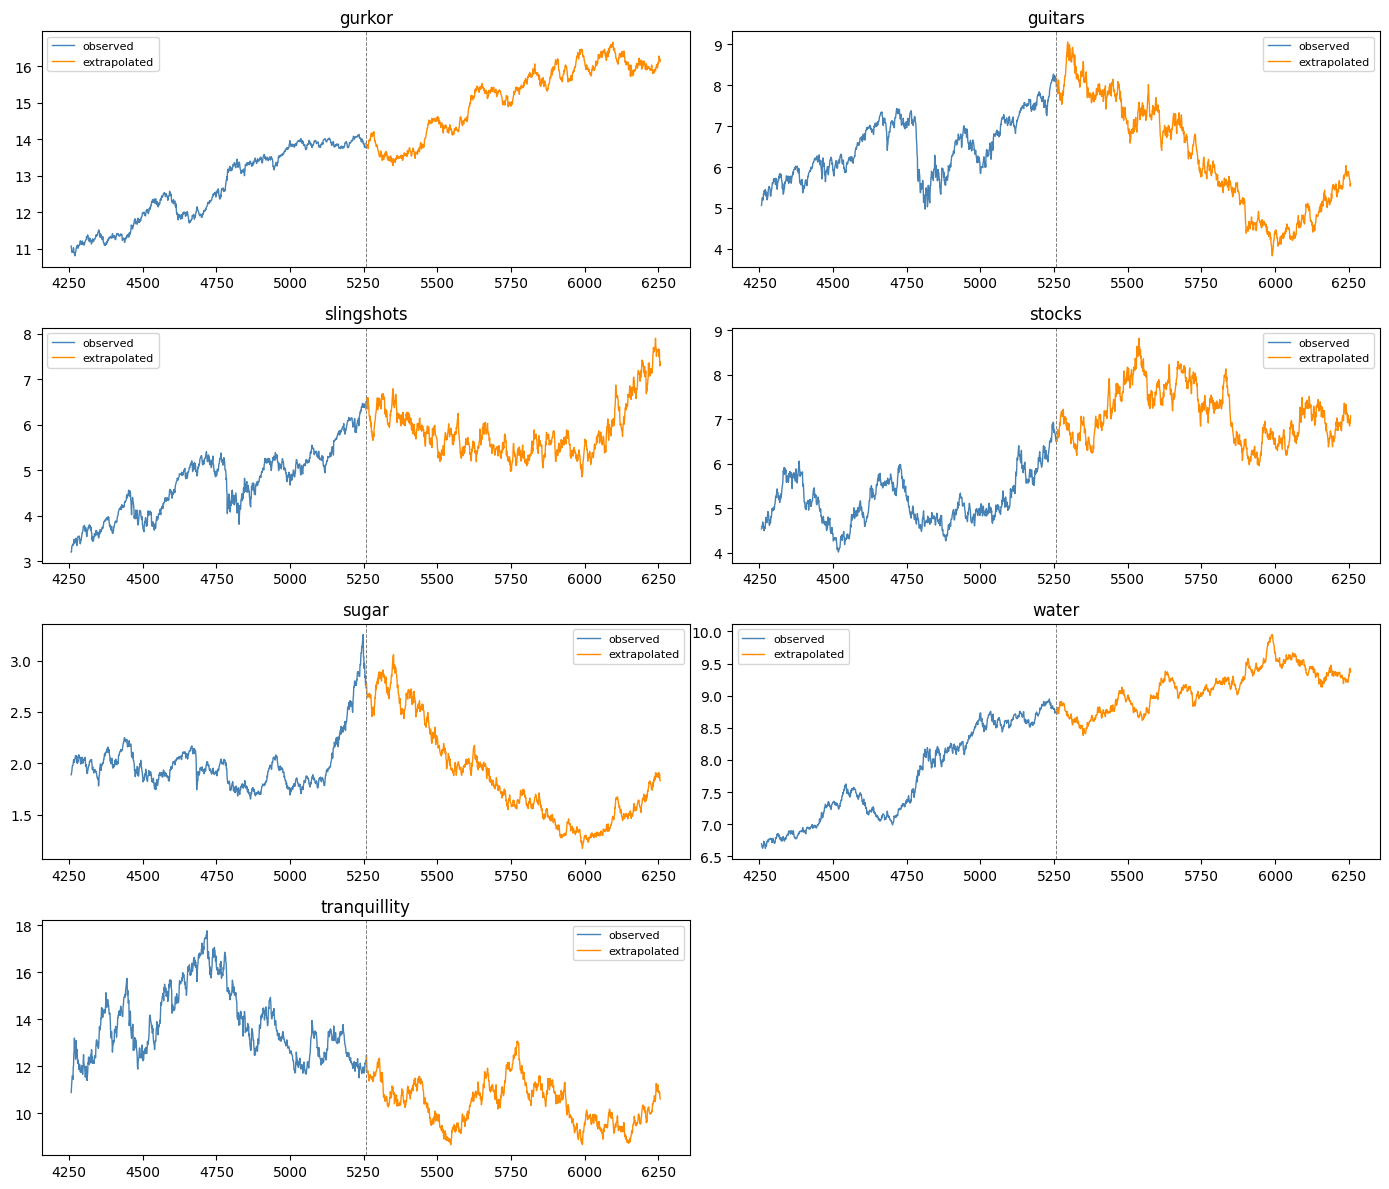

In [66]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
tail = 1000
for ax, col in zip(axes.flat, var_names):
    ax.plot(df_prices.index[-tail:], df_prices[col].iloc[-tail:],
            color='steelblue', lw=1, label='observed')
    ax.plot(df_extrap.index, df_extrap[col],
            color='darkorange', lw=1, label='extrapolated')
    ax.axvline(last_day, color='grey', lw=0.7, ls='--')
    ax.set_title(col)
    ax.legend(loc='best', fontsize=8)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()


In [67]:
compare = pd.DataFrame({
    'obs_std':  df_returns_centered.std(),
    'sim_std':  pd.Series(Y_extrap[2:].std(axis=0), index=var_names),
})
print(compare.round(5))

print("\nObserved correlation:")
obs_corr = df_returns_centered.corr()
print(obs_corr.round(2))

print("\nSimulated correlation (300 days — noisy):")
sim_corr = pd.DataFrame(Y_extrap[2:], columns=var_names).corr()
print(sim_corr.round(2))

# Calculate MAE for correlation matrices
mae_corr = np.abs(obs_corr - sim_corr).values.mean()
print(f"\nMAE (correlation matrices): {mae_corr:.5f}")

              obs_std  sim_std
gurkor        0.00413  0.00405
guitars       0.01595  0.01580
slingshots    0.01637  0.01664
stocks        0.01483  0.01454
sugar         0.01592  0.01552
water         0.00349  0.00341
tranquillity  0.01391  0.01384

Observed correlation:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00    -0.38       -0.33   -0.04  -0.09   0.63         -0.16
guitars        -0.38     1.00        0.59    0.02   0.21  -0.45          0.29
slingshots     -0.33     0.59        1.00    0.02   0.14  -0.31          0.23
stocks         -0.04     0.02        0.02    1.00  -0.03  -0.05          0.00
sugar          -0.09     0.21        0.14   -0.03   1.00  -0.11          0.15
water           0.63    -0.45       -0.31   -0.05  -0.11   1.00         -0.19
tranquillity   -0.16     0.29        0.23    0.00   0.15  -0.19          1.00

Simulated correlation (300 days — noisy):
              gurkor  guitars  slingshots  stocks  sugar  wate

Excess kurtosis:
                obs  sim_gauss
gurkor         3.87       0.11
guitars        6.52       0.11
slingshots     5.21       0.02
stocks         0.02      -0.06
sugar         14.84      -0.19
water          1.70      -0.24
tranquillity   2.39      -0.11
Off-diagonal MAE on log-vol correlations: 0.473


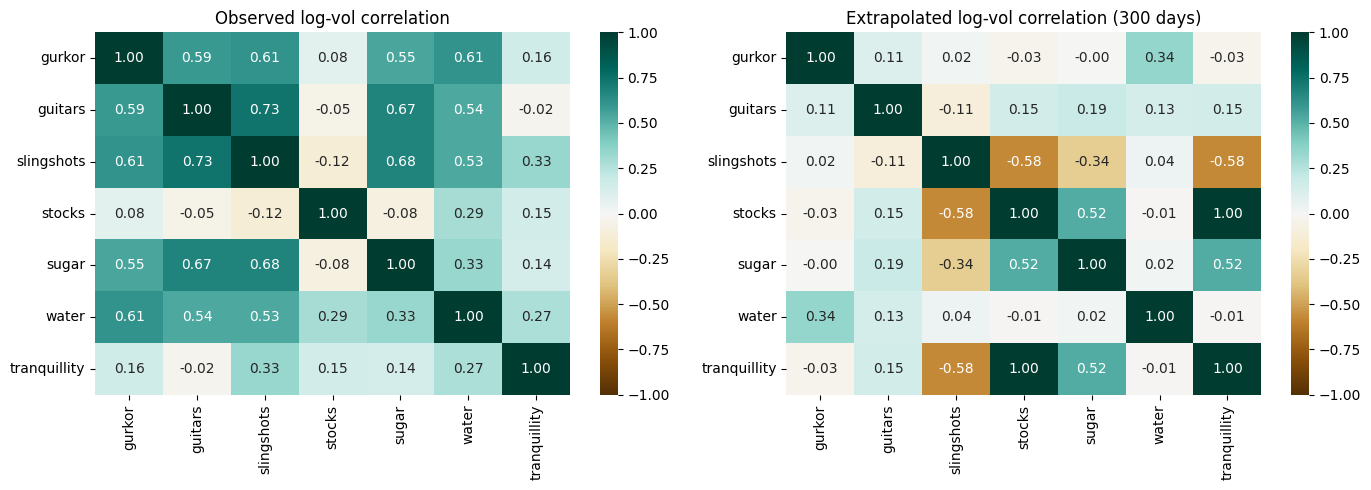

In [68]:
# Marginal kurtosis comparison
kurt = pd.DataFrame({
    'obs':       df_returns_centered.kurt(),
    'sim_gauss': pd.DataFrame(Y_extrap[2:],   columns=var_names).kurt(),
})
print("Excess kurtosis:")
print(kurt.round(2))
from arch import arch_model

def fit_log_h(returns_df):
    out = pd.DataFrame(index=returns_df.index, columns=returns_df.columns, dtype=float)
    for col in returns_df.columns:
        # scale up to keep the optimizer happy (arch prefers ~1-sized series)
        res = arch_model(returns_df[col] * 1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
        out[col] = np.log(res.conditional_volatility ** 2)
    return out 

# Observed: use the same centered returns we trained the VAR on
log_h_obs = fit_log_h(df_returns_centered)

# Simulated: rebuild centered returns from the extrapolation
df_sim_returns = pd.DataFrame(Y_extrap[2:], index=future_days, columns=var_names)
log_h_sim = fit_log_h(df_sim_returns)

corr_obs = log_h_obs.corr()
corr_sim = log_h_sim.corr()

mask = ~np.eye(k, dtype=bool)
mae_vol_corr = np.mean(np.abs(corr_obs.values[mask] - corr_sim.values[mask]))
print(f"Off-diagonal MAE on log-vol correlations: {mae_vol_corr:.3f}")

import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_obs, annot=True, fmt='.2f', cmap='BrBG', center=0,
            vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Observed log-vol correlation')
sns.heatmap(corr_sim, annot=True, fmt='.2f', cmap='BrBG', center=0,
            vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Extrapolated log-vol correlation (300 days)')
plt.tight_layout()
plt.show()


In [69]:
from scipy.stats import norm, skew, kurtosis

H_tail = 200
alphas = [0.001, 0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99, 0.999]
z = {a: norm.ppf(a) for a in alphas}

def cornish_fisher_q(z_a, S, K):
    return (z_a
            + (z_a**2 - 1) * S / 6
            + (z_a**3 - 3*z_a) * K / 24
            - (2*z_a**3 - 5*z_a) * S**2 / 36)

log_ret = np.log(df_prices).diff().dropna()

records = []
for col in var_names:
    r = log_ret[col].values
    mu, sd = r.mean(), r.std(ddof=1)
    S, K   = skew(r), kurtosis(r)            # K is excess by default

    mu_H = H_tail * mu
    sd_H = np.sqrt(H_tail) * sd
    S_H  = S / np.sqrt(H_tail)
    K_H  = K / H_tail

    # Rolling-empirical: every overlapping 200-day log-return sum
    roll = pd.Series(r).rolling(H_tail).sum().dropna().values

    row = {'series': col, 'mu_H': mu_H, 'sd_H': sd_H, 'S_H': S_H, 'K_H': K_H,
           'n_windows': len(roll)}
    for a in alphas:
        row[f'gauss_{int(a*1000)/10}'] = mu_H + sd_H * z[a]
        row[f'cf_{int(a*1000)/10}']    = mu_H + sd_H * cornish_fisher_q(z[a], S_H, K_H)
        row[f'emp_{int(a*1000)/10}']   = np.quantile(roll, a)
    records.append(row)

tail_df = pd.DataFrame(records).set_index('series')

# Pretty-print the asymmetric tail quantiles as price-multiples (exp of log return)
def fmt_block(qs):
    sub = tail_df[[f'{m}_{q}' for m in ['gauss','cf','emp'] for q in qs]]
    sub = np.exp(sub)  # convert log-return to price multiple of P_0
    return sub.round(3)

print("200-day price-multiple quantiles (P_T / P_0), left tail:")
print(fmt_block(['0.1', '1.0', '5.0']))
print("\n200-day price-multiple quantiles, right tail:")
print(fmt_block(['95.0', '99.0', '99.9']))
print("\nMedian (50%) — sanity check that drift agrees across methods:")
print(fmt_block(['50.0']))

200-day price-multiple quantiles (P_T / P_0), left tail:
              gauss_0.1  gauss_1.0  gauss_5.0  cf_0.1  cf_1.0  cf_5.0  \
series                                                                  
gurkor            0.869      0.908      0.945   0.867   0.908   0.945   
guitars           0.496      0.589      0.687   0.494   0.588   0.687   
slingshots        0.510      0.608      0.713   0.502   0.605   0.711   
stocks            0.529      0.621      0.717   0.528   0.620   0.716   
sugar             0.498      0.592      0.691   0.489   0.588   0.690   
water             0.887      0.921      0.952   0.886   0.920   0.952   
tranquillity      0.553      0.642      0.735   0.548   0.640   0.734   

              emp_0.1  emp_1.0  emp_5.0  
series                                   
gurkor          0.943    0.951    0.974  
guitars         0.478    0.510    0.602  
slingshots      0.493    0.591    0.709  
stocks          0.545    0.616    0.766  
sugar           0.515    0.567   

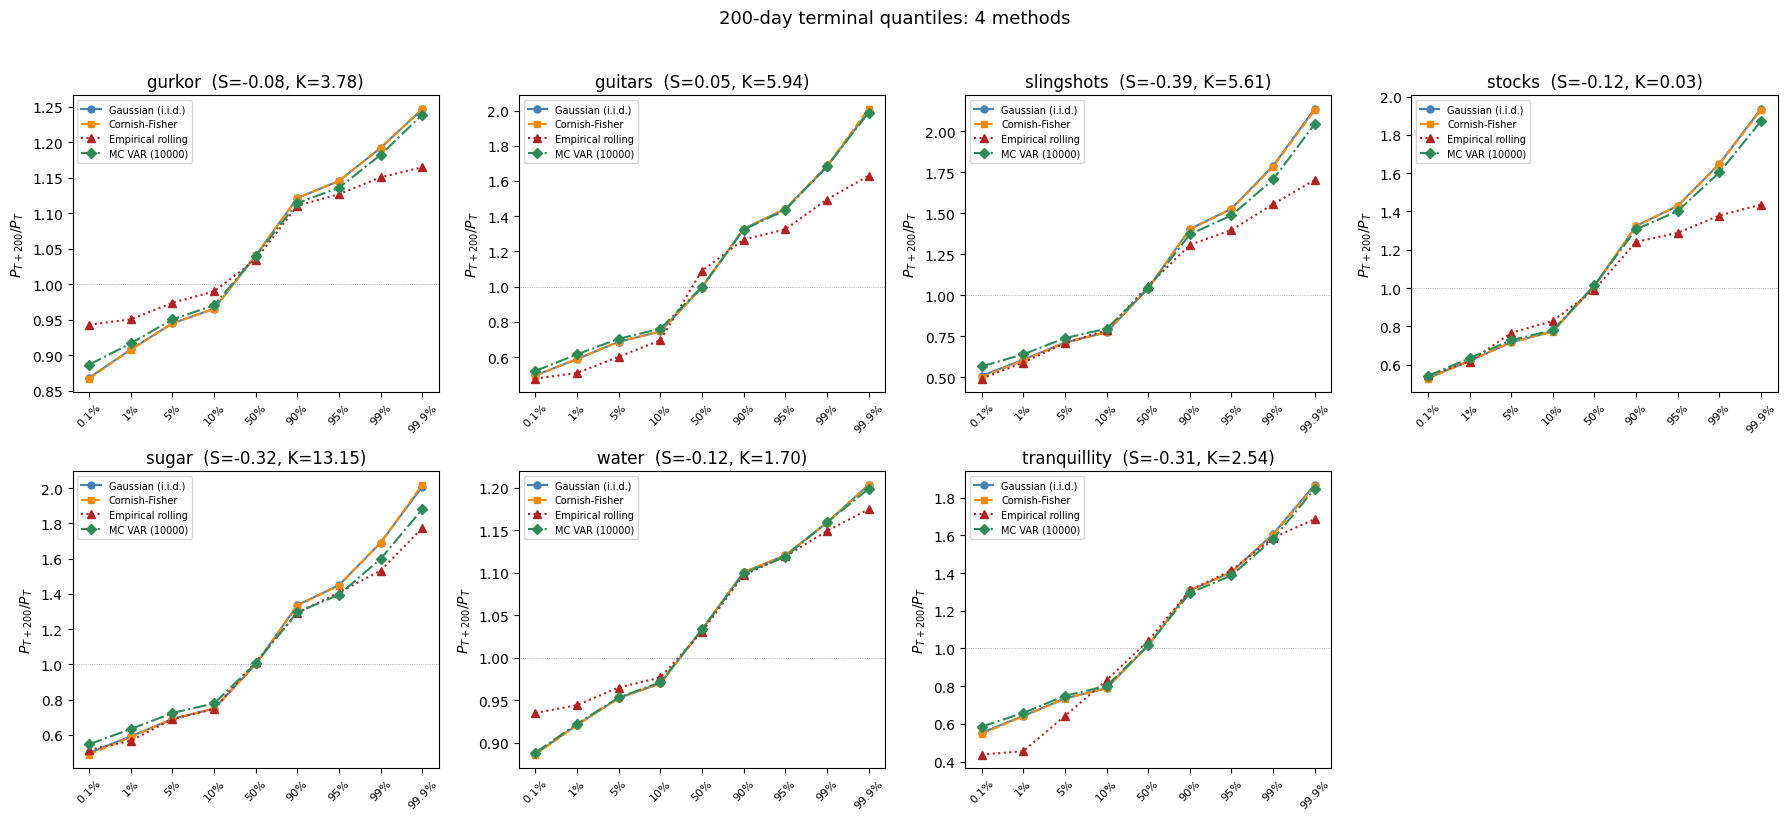

In [70]:
# Monte Carlo: run the Gaussian VAR sim n_mc times over H_tail days.
# Save full price paths and terminal log returns so we can build both
# quantile fans (over time) and point quantiles (at H_tail).
n_mc = 10000
rng_mc = np.random.default_rng(42)

mc_prices = np.zeros((n_mc, H_tail, k))
mc_term_log_ret = np.zeros((n_mc, k))

for s in range(n_mc):
    Yp = np.zeros((H_tail + 2, k))
    Yp[0] = Y[-2]
    Yp[1] = Y[-1]
    for t in range(2, H_tail + 2):
        eps = L_eps @ rng_mc.standard_normal(k)
        Yp[t] = Phi1 @ Yp[t - 1] + Phi2 @ Yp[t - 2] + eps
    simple_ret_path = Yp[2:] + mean_return.values
    price_path = last_price * np.cumprod(1.0 + simple_ret_path, axis=0)
    mc_prices[s] = price_path
    mc_term_log_ret[s] = np.log(price_path[-1] / last_price)

# Add MC terminal quantiles to the comparison table
for j, col in enumerate(var_names):
    for a in alphas:
        tail_df.loc[col, f'mc_{int(a*1000)/10}'] = np.quantile(mc_term_log_ret[:, j], a)

# Plot all four methods side by side
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
alpha_plot = [0.001, 0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99, 0.999]
x_pos = np.arange(len(alpha_plot))

for ax, col in zip(axes.flat, var_names):
    g  = [np.exp(tail_df.loc[col, f'gauss_{int(a*1000)/10}']) for a in alpha_plot]
    cf = [np.exp(tail_df.loc[col, f'cf_{int(a*1000)/10}'])    for a in alpha_plot]
    em = [np.exp(tail_df.loc[col, f'emp_{int(a*1000)/10}'])   for a in alpha_plot]
    mc = [np.exp(tail_df.loc[col, f'mc_{int(a*1000)/10}'])    for a in alpha_plot]
    ax.plot(x_pos, g,  'o-',  color='steelblue',  label='Gaussian (i.i.d.)', ms=5)
    ax.plot(x_pos, cf, 's--', color='darkorange', label='Cornish-Fisher',    ms=5)
    ax.plot(x_pos, em, '^:',  color='firebrick',  label='Empirical rolling', ms=6)
    ax.plot(x_pos, mc, 'D-.', color='seagreen',   label=f'MC VAR ({n_mc})',  ms=5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'{a*100:g}%' for a in alpha_plot], rotation=45, fontsize=8)
    ax.axhline(1.0, color='grey', lw=0.5, ls=':')
    ax.set_title(f"{col}  (S={tail_df.loc[col,'S_H']*np.sqrt(H_tail):.2f}, "
                 f"K={tail_df.loc[col,'K_H']*H_tail:.2f})")
    ax.set_ylabel(f'$P_{{T+{H_tail}}}/P_T$')
    ax.legend(fontsize=7, loc='best')
axes.flat[-1].axis('off')
plt.suptitle(f'{H_tail}-day terminal quantiles: 4 methods',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

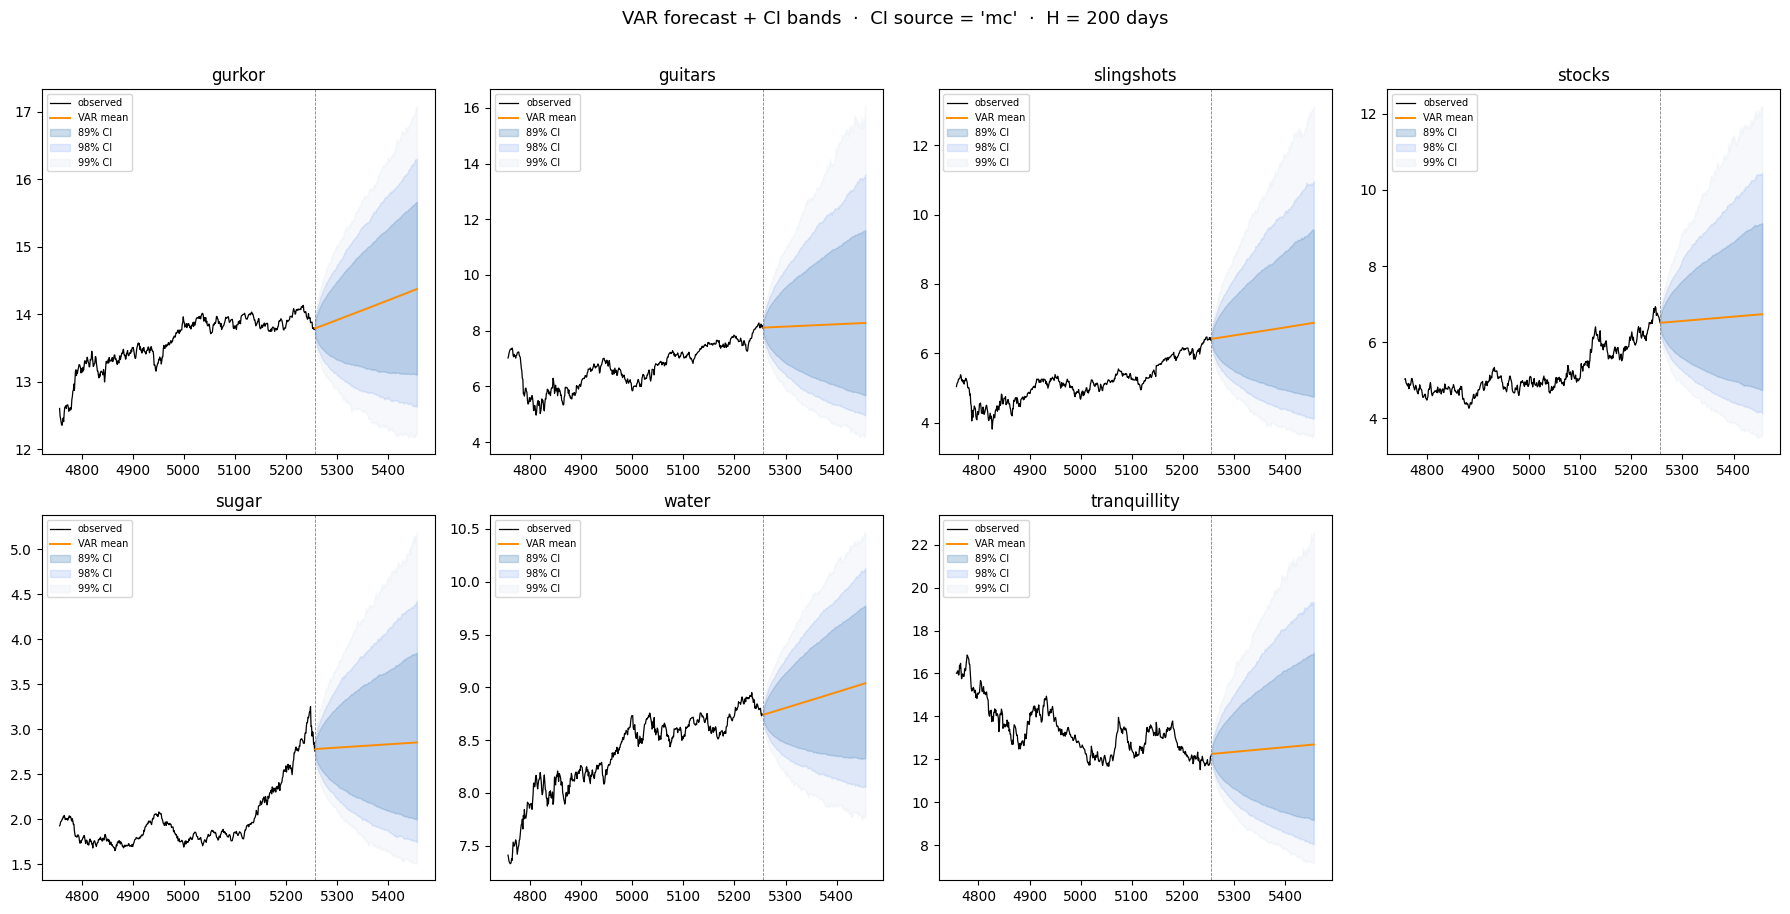

In [71]:
# Toggle: choose CI source.
CI_METHOD = 'mc'   # one of: 'gaussian', 'cf', 'empirical', 'mc'
CI_BANDS  = [(0.05, 0.95), (0.01, 0.99), (0.001, 0.999)]   # 90 / 98 / 99.8%

# Deterministic VAR forecast (innovations = 0) — the conditional mean path
Y_det = np.zeros((H_tail + 2, k))
Y_det[0] = Y[-2]
Y_det[1] = Y[-1]
for t in range(2, H_tail + 2):
    Y_det[t] = Phi1 @ Y_det[t - 1] + Phi2 @ Y_det[t - 2]
returns_det = Y_det[2:] + mean_return.values
prices_det  = last_price * np.cumprod(1.0 + returns_det, axis=0)

future_days_tail = np.arange(last_day + 1, last_day + 1 + H_tail)
t_axis = np.arange(1, H_tail + 1)

def terminal_log_quantile(method, j, a):
    """Terminal H_tail log-return quantile for series j at probability a."""
    key = f"{method}_{int(a*1000)/10}"
    return tail_df.loc[var_names[j], key]

def ci_band(method, j, a_lo, a_hi):
    """Return arrays (low, high) of price levels along t_axis."""
    P0 = last_price[j]
    if method == 'mc':
        low  = np.quantile(mc_prices[:, :, j], a_lo, axis=0)
        high = np.quantile(mc_prices[:, :, j], a_hi, axis=0)
    else:
        q_lo = terminal_log_quantile(method, j, a_lo)
        q_hi = terminal_log_quantile(method, j, a_hi)
        # sqrt-time scaling of the *log-return* quantile
        scale  = np.sqrt(t_axis / H_tail)
        # also scale the drift linearly with t
        mu_H   = tail_df.loc[var_names[j], 'mu_H']
        drift  = mu_H * t_axis / H_tail
        low_lr  = drift + (q_lo - mu_H) * scale
        high_lr = drift + (q_hi - mu_H) * scale
        low  = P0 * np.exp(low_lr)
        high = P0 * np.exp(high_lr)
    return low, high

# Plot
fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex=False)
tail_obs = 500
band_alphas = [0.28, 0.18, 0.10]
band_colors = ['steelblue', 'cornflowerblue', 'lightsteelblue']

for ax, col, j in zip(axes.flat, var_names, range(k)):
    ax.plot(df_prices.index[-tail_obs:], df_prices[col].iloc[-tail_obs:],
            color='black', lw=0.9, label='observed')
    ax.plot(future_days_tail, prices_det[:, j],
            color='darkorange', lw=1.4, label='VAR mean')

    for (a_lo, a_hi), fa, fc in zip(CI_BANDS, band_alphas, band_colors):
        low, high = ci_band(CI_METHOD, j, a_lo, a_hi)
        ax.fill_between(future_days_tail, low, high,
                        color=fc, alpha=fa,
                        label=f'{int((a_hi - a_lo) * 100)}% CI')

    ax.axvline(last_day, color='grey', lw=0.6, ls='--')
    ax.set_title(col)
    ax.legend(fontsize=7, loc='best')
axes.flat[-1].axis('off')
plt.suptitle(f"VAR forecast + CI bands  ·  CI source = '{CI_METHOD}'  ·  H = {H_tail} days",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.show()